In [84]:
# 🎴 Slay the Spire RL Experiments
# Эксперименты с различными архитектурами и подходами к обучению агента

import json
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
import numpy as np
import random
import pickle
from collections import deque, namedtuple
import matplotlib.pyplot as plt
import subprocess
import copy

# Константы
INPUT_NEURS_BY_MOB = {0: 22, 1: 22, 2: 31}
OUTPUT_NEURS_BY_MOB = {0: 6, 1: 6, 2: 11}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [142]:
# ============================================================================
# 🔧 УТИЛИТЫ
# ============================================================================

def state_to_tuple(d, input_size):
    """Конвертирует JSON состояние в вектор признаков (с нормализацией)"""
    res = np.zeros(input_size)
    if d["game_state"] == 0:
        # Нормализуем все признаки в диапазон ~0-1
        res[0] = d["energy"] / 3.0           # энергия: 0-3 → 0-1
        res[1] = d["player"]["hp"] / 88.0    # HP игрока: 0-80 → 0-1
        res[2] = d["player"]["def"] / 10.0   # блок: 0-10 → 0-1
        last = 3
        for i in range(len(d["hand"])):
            res[last + i] = d["hand"][i] / 2.0  # card_id: 0-2 → 0-1
        last += len(d["hand"])
        for i in range(len(d["pool"])):
            res[last + i] = d["pool"][i] / 2.0
        last += len(d["pool"])
        for i in range(len(d["mobs"])):
            res[last] = d["mobs"][i]["type"] / 5.0       # тип моба
            res[last + 1] = d["mobs"][i]["hp"] / 60.0     # HP моба: 0-60 → 0-1
            res[last + 2] = d["mobs"][i]["def"] / 10.0    # блок моба
            res[last + 3] = d["mobs"][i]["move"] / 5.0    # move_id
            res[last + 4] = d["mobs"][i]["effects"][0] / 5.0  # Vulnerable
            res[last + 5] = d["mobs"][i]["effects"][1] / 5.0  # Weak
            res[last + 6] = d["mobs"][i]["effects"][3] / 5.0  # Strength
            res[last + 7] = d["mobs"][i]["effects"][4] / 5.0  # Ritual
            res[last + 8] = d["mobs"][i]["effects"][5] / 10.0 # CurlUp
            last += 9

    return res


def to_one_hot(y, n_dims=None):
    """Преобразует индексы в one-hot векторы"""
    y_tensor = y.data if isinstance(y, Variable) else y
    y_tensor = y_tensor.type(torch.LongTensor).view(-1, 1)
    n_dims = n_dims if n_dims is not None else int(torch.max(y_tensor)) + 1
    y_one_hot = torch.zeros(y_tensor.size()[0], n_dims).scatter_(1, y_tensor, 1)
    return Variable(y_one_hot) if isinstance(y, Variable) else y_one_hot

In [86]:
# ============================================================================
# 🧠 АРХИТЕКТУРЫ НЕЙРОСЕТЕЙ
# ============================================================================

# 1. Baseline MLP (как в train.py)
class BaselineMLP(nn.Module):
    """Оригинальная архитектура из train.py"""
    def __init__(self, input_size, output_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )
    
    def forward(self, x):
        return self.net(x)


# 2. Deeper MLP с BatchNorm
class DeeperMLP(nn.Module):
    """Более глубокая сеть с BatchNorm и Dropout для регуляризации"""
    def __init__(self, input_size, output_size, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            
            nn.Linear(128, output_size)
        )
    
    def forward(self, x):
        return self.net(x)


# 3. Dueling DQN - разделяет Q-value на Value и Advantage
class DuelingDQN(nn.Module):
    """Dueling DQN: Q(s,a) = V(s) + A(s,a) - mean(A(s,a))"""
    def __init__(self, input_size, output_size, hidden=256):
        super().__init__()
        
        # Общий feature extractor
        self.feature = nn.Sequential(
            nn.Linear(input_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )
        
        # Value stream: V(s)
        self.value_stream = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Linear(128, 1)
        )
        
        # Advantage stream: A(s,a)
        self.advantage_stream = nn.Sequential(
            nn.Linear(hidden, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )
    
    def forward(self, x):
        features = self.feature(x)
        value = self.value_stream(features)
        advantage = self.advantage_stream(features)
        # Q = V + (A - mean(A))
        q_values = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q_values


In [106]:
# 4. Noisy DQN - шумные слои вместо epsilon-greedy
class NoisyLinear(nn.Module):
    """Factorized Noisy Linear layer для exploration"""
    def __init__(self, in_features, out_features, sigma_init=0.5):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        self.register_buffer('weight_epsilon', torch.empty(out_features, in_features))
        
        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        self.register_buffer('bias_epsilon', torch.empty(out_features))
        
        self.sigma_init = sigma_init
        self.reset_parameters()
        self.reset_noise()
    
    def reset_parameters(self):
        mu_range = 1 / np.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.sigma_init / np.sqrt(self.in_features))
        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.sigma_init / np.sqrt(self.out_features))
    
    def reset_noise(self):
        epsilon_in = self._scale_noise(self.in_features)
        epsilon_out = self._scale_noise(self.out_features)
        self.weight_epsilon.copy_(epsilon_out.outer(epsilon_in))
        self.bias_epsilon.copy_(epsilon_out)
    
    def _scale_noise(self, size):
        x = torch.randn(size)
        return x.sign().mul_(x.abs().sqrt_())
    
    def forward(self, x):
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias = self.bias_mu + self.bias_sigma * self.bias_epsilon
        else:
            weight = self.weight_mu
            bias = self.bias_mu
        return F.linear(x, weight, bias)


class NoisyDQN(nn.Module):
    """DQN с Noisy layers для автоматического exploration"""
    def __init__(self, input_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 256)
        self.noisy1 = NoisyLinear(256, 128)
        self.noisy2 = NoisyLinear(128, output_size)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.noisy1(x))
        return self.noisy2(x)
    
    def reset_noise(self):
        self.noisy1.reset_noise()
        self.noisy2.reset_noise()


In [88]:
# ============================================================================
# 📦 EXPERIENCE REPLAY BUFFERS
# ============================================================================

Transition = namedtuple('Transition', ('state', 'action', 'reward', 'next_state', 'done'))


class ReplayBuffer:
    """Простой Replay Buffer с равномерным сэмплированием"""
    def __init__(self, capacity=10000):
        self.buffer = deque(maxlen=capacity)
    
    def push(self, state, action, reward, next_state, done):
        self.buffer.append(Transition(state, action, reward, next_state, done))
    
    def sample(self, batch_size):
        transitions = random.sample(self.buffer, batch_size)
        batch = Transition(*zip(*transitions))
        return (
            np.array(batch.state),
            np.array(batch.action),
            np.array(batch.reward),
            np.array(batch.next_state),
            np.array(batch.done)
        )
    
    def __len__(self):
        return len(self.buffer)


class PrioritizedReplayBuffer:
    """Prioritized Experience Replay - сэмплирует важные переходы чаще"""
    def __init__(self, capacity=10000, alpha=0.6, beta=0.4, beta_increment=0.001):
        self.capacity = capacity
        self.alpha = alpha  # приоритетность (0 = uniform, 1 = full priority)
        self.beta = beta    # importance sampling weight
        self.beta_increment = beta_increment
        
        self.buffer = []
        self.priorities = np.zeros(capacity, dtype=np.float32)
        self.position = 0
    
    def push(self, state, action, reward, next_state, done):
        max_priority = self.priorities.max() if self.buffer else 1.0
        
        if len(self.buffer) < self.capacity:
            self.buffer.append(Transition(state, action, reward, next_state, done))
        else:
            self.buffer[self.position] = Transition(state, action, reward, next_state, done)
        
        self.priorities[self.position] = max_priority
        self.position = (self.position + 1) % self.capacity
    
    def sample(self, batch_size):
        if len(self.buffer) == self.capacity:
            priorities = self.priorities
        else:
            priorities = self.priorities[:len(self.buffer)]
        
        probs = priorities ** self.alpha
        probs /= probs.sum()
        
        indices = np.random.choice(len(self.buffer), batch_size, p=probs)
        
        # Importance sampling weights
        weights = (len(self.buffer) * probs[indices]) ** (-self.beta)
        weights /= weights.max()
        
        self.beta = min(1.0, self.beta + self.beta_increment)
        
        transitions = [self.buffer[i] for i in indices]
        batch = Transition(*zip(*transitions))
        
        return (
            np.array(batch.state),
            np.array(batch.action),
            np.array(batch.reward),
            np.array(batch.next_state),
            np.array(batch.done),
            indices,
            weights
        )
    
    def update_priorities(self, indices, td_errors):
        for idx, error in zip(indices, td_errors):
            self.priorities[idx] = abs(error) + 1e-5
    
    def __len__(self):
        return len(self.buffer)


In [150]:
# ============================================================================
# 🎯 DQN AGENT
# ============================================================================

class DQNAgent:
    """DQN Agent с поддержкой Double DQN и различных архитектур"""
    def __init__(self, 
                 input_size,
                 output_size,
                 network_class=BaselineMLP,
                 lr=1e-4, 
                 gamma=0.99,
                 buffer_size=10000,
                 batch_size=64,
                 use_double_dqn=True,
                 target_update_freq=100,
                 use_prioritized=False,
                 weight_decay=1e-4,
                 use_soft_clipping=False):  # Включить для проблемных мобов (Louses)
        
        self.gamma = gamma
        self.batch_size = batch_size
        self.use_double_dqn = use_double_dqn
        self.target_update_freq = target_update_freq
        self.use_prioritized = use_prioritized
        self.use_soft_clipping = use_soft_clipping
        self.update_count = 0
        
        # Networks
        self.policy_net = network_class(input_size=input_size, output_size=output_size).to(device)
        self.target_net = network_class(input_size=input_size, output_size=output_size).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        # Optimizer с weight decay (L2 регуляризация) - предотвращает рост весов
        self.optimizer = torch.optim.Adam(self.policy_net.parameters(), lr=lr, weight_decay=weight_decay)
        
        # Replay buffer
        if use_prioritized:
            self.buffer = PrioritizedReplayBuffer(buffer_size)
        else:
            self.buffer = ReplayBuffer(buffer_size)
        
        # Для NoisyDQN
        self.is_noisy = network_class == NoisyDQN
    
    def get_action(self, state, n_actions, epsilon=0):
        """Выбор действия с epsilon-greedy (или без для NoisyDQN)"""
        if self.is_noisy:
            epsilon = 0  # Noisy net сам делает exploration
        
        if random.random() < epsilon:
            return random.randrange(n_actions)
        
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = self.policy_net(state_tensor)
            # Выбираем только из доступных действий
            valid_q = q_values[0, :n_actions]
            return valid_q.argmax().item()
    
    def push_transition(self, state, action, reward, next_state, done):
        self.buffer.push(state, action, reward, next_state, done)
    
    def train_step(self):
        """Один шаг обучения на батче из replay buffer"""
        if len(self.buffer) < self.batch_size:
            return None
        
        if self.use_prioritized:
            states, actions, rewards, next_states, dones, indices, weights = self.buffer.sample(self.batch_size)
            weights = torch.FloatTensor(weights).to(device)
        else:
            states, actions, rewards, next_states, dones = self.buffer.sample(self.batch_size)
            weights = torch.ones(self.batch_size).to(device)
        
        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).to(device)
        rewards = torch.FloatTensor(rewards).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.FloatTensor(dones).to(device)
        
        # Текущие Q-values
        current_q = self.policy_net(states).gather(1, actions.unsqueeze(1)).squeeze(1)
        
        # Soft clipping через tanh (опционально, для проблемных мобов типа Louses)
        if self.use_soft_clipping:
            current_q = 100.0 * torch.tanh(current_q / 100.0)
        
        # Target Q-values
        with torch.no_grad():
            if self.use_double_dqn:
                # Double DQN: выбираем действие по policy_net, оцениваем по target_net
                next_actions = self.policy_net(next_states).argmax(1)
                next_q = self.target_net(next_states).gather(1, next_actions.unsqueeze(1)).squeeze(1)
            else:
                # Обычный DQN
                next_q = self.target_net(next_states).max(1)[0]
            
            # Clipping target Q-values для стабильности (согласовано с current_q)
            next_q = torch.clamp(next_q, -100, 100)
            target_q = rewards + (1 - dones) * self.gamma * next_q
            target_q = torch.clamp(target_q, -100, 100)
        
        # TD error для prioritized replay
        td_errors = (current_q - target_q).detach().cpu().numpy()
        
        # Loss
        loss = (weights * F.smooth_l1_loss(current_q, target_q, reduction='none')).mean()
        
        # Диагностика при аномально высоком loss (можно закомментировать после отладки)
        if loss.item() > 100:
            print(f"⚠️ HIGH LOSS: {loss.item():.2f}")
            print(f"   current_q: [{current_q.min().item():.2f}, {current_q.max().item():.2f}]")
            print(f"   target_q: [{target_q.min().item():.2f}, {target_q.max().item():.2f}]")
        
        # Optimize
        self.optimizer.zero_grad()
        loss.backward()
        # Агрессивный gradient clipping для стабильности
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()
        
        # Update priorities
        if self.use_prioritized:
            self.buffer.update_priorities(indices, td_errors)
        
        # Update target network
        self.update_count += 1
        if self.update_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())
        
        # Reset noise for NoisyDQN
        if self.is_noisy:
            self.policy_net.reset_noise()
            self.target_net.reset_noise()
        
        return loss.item()
    
    def save(self, path):
        torch.save({
            'policy_net': self.policy_net.state_dict(),
            'target_net': self.target_net.state_dict(),
            'optimizer': self.optimizer.state_dict(),
        }, path)
    
    def load(self, path):
        checkpoint = torch.load(path)
        self.policy_net.load_state_dict(checkpoint['policy_net'])
        self.target_net.load_state_dict(checkpoint['target_net'])
        self.optimizer.load_state_dict(checkpoint['optimizer'])


In [90]:
# ============================================================================
# 🎮 ОБЁРТКА ДЛЯ ЭМУЛЯТОРА
# ============================================================================

class STSEmulator:
    """Обёртка для взаимодействия с C++ эмулятором через subprocess"""
    def __init__(self, emulator_path="../emulator/build/emulator"):
        self.emulator_path = emulator_path
        self.process = None
    
    def start(self):
        """Запускает процесс эмулятора (вызывать один раз!)"""
        if self.process is None:
            self.process = subprocess.Popen(
                [self.emulator_path],
                stdin=subprocess.PIPE,
                stdout=subprocess.PIPE,
                stderr=subprocess.PIPE,
                text=True,
                bufsize=1
            )
    
    def send(self, action):
        """Отправляет действие и получает ответ"""
        try:
            self.process.stdin.write(f"{action}\n")
            self.process.stdin.flush()
            
            line = self.process.stdout.readline().strip()
            if not line:
                return None, None, None
            reward = float(line)
            state = json.loads(self.process.stdout.readline().strip())
            actions = json.loads(self.process.stdout.readline().strip())
            
            return reward, state, actions
        except (BrokenPipeError, ValueError, OSError) as e:
            print(f"Emulator error: {e}")
            return None, None, None
    
    def reset(self):
        """Сбрасывает игру (отправляет -1)"""
        return self.send(-1)
    
    def close(self):
        """Завершает эмулятор (отправляет -2)"""
        if self.process:
            try:
                self.process.stdin.write("-2\n")
                self.process.stdin.flush()
            except:
                pass
            try:
                self.process.terminate()
                self.process.wait(timeout=1)
            except:
                try:
                    self.process.kill()
                except:
                    pass
            self.process = None


In [144]:
# ============================================================================
# 🏋️ ТРЕНИРОВОЧНЫЙ ЦИКЛ
# ============================================================================

def train_agent(agent, 
                mob_id=0,  # 0=JawWorm, 1=Cultist, 2=Louses
                n_epochs=100, 
                games_per_epoch=50,
                epsilon_start=0.3,
                epsilon_end=0.01,
                epsilon_decay=0.99,
                train_every=1,
                verbose=True):
    """
    Основной тренировочный цикл
    
    Args:
        agent: DQNAgent
        mob_id: 0 для JawWorm, 1 для Cultist
        n_epochs: количество эпох
        games_per_epoch: игр на эпоху
        epsilon_start/end/decay: параметры epsilon-greedy
        train_every: как часто делать train_step
    """
    mob_names = {0: "JawWorm", 1: "Cultist", 2: "Louses"}
    print(f"🎯 Training against {mob_names[mob_id]}")
    
    emulator = STSEmulator()
    emulator.start()  # Запускаем один раз!
    
    epsilon = epsilon_start
    all_rewards = []
    all_losses = []
    step_count = 0
    
    try:
        for epoch in range(n_epochs):
            epoch_rewards = []
            epoch_losses = []
            
            for game in range(games_per_epoch):
                total_reward = 0
                
                # Reset и выбор моба
                reward, state, actions = emulator.reset()
                if reward is None:
                    print("Emulator reset failed, restarting...")
                    emulator.close()
                    emulator.start()
                    reward, state, actions = emulator.reset()
                total_reward += reward
                
                reward, state, actions = emulator.send(mob_id)
                total_reward += reward
                l_state = state_to_tuple(state, INPUT_NEURS_BY_MOB[mob_id])
                
                # Игровой цикл
                done = False
                while not done:
                    # Выбор действия
                    action = agent.get_action(l_state, len(actions), epsilon)
                    
                    # Шаг в среде
                    reward, next_state, next_actions = emulator.send(action)
                    if reward is None:
                        print("Emulator error during game")
                        break
                    
                    l_next_state = state_to_tuple(next_state, INPUT_NEURS_BY_MOB[mob_id])
                    done = next_state["game_state"] in [1, 2]  # Lose=1, Win=2
                    
                    # REWARD CLIPPING - достаточно широкий чтобы включить терминальные награды (~14)
                    clipped_reward = np.clip(reward, -15, 15)
                    
                    # Сохраняем переход
                    agent.push_transition(l_state, action, clipped_reward, l_next_state, float(done))
                    total_reward += reward
                    
                    # Обучение
                    step_count += 1
                    if step_count % train_every == 0:
                        loss = agent.train_step()
                        if loss is not None:
                            epoch_losses.append(loss)
                    
                    l_state = l_next_state
                    actions = next_actions
                
                epoch_rewards.append(total_reward)
                # НЕ закрываем эмулятор! Следующая игра начнётся с reset()
            
            # Статистика эпохи
            mean_reward = np.mean(epoch_rewards)
            mean_loss = np.mean(epoch_losses) if epoch_losses else 0
            all_rewards.append(mean_reward)
            all_losses.append(mean_loss)
            
            epsilon = max(epsilon_end, epsilon * epsilon_decay)
            
            if verbose and epoch % 5 == 0:
                print(f"Epoch {epoch:3d} | Reward: {mean_reward:7.2f} | Loss: {mean_loss:.4f} | ε: {epsilon:.3f}")
    
    except KeyboardInterrupt:
        print("\n⚠️ Training interrupted!")
    finally:
        emulator.close()  # Закрываем только в конце всего обучения
    
    return all_rewards, all_losses


In [92]:
# ============================================================================
# 📊 ВИЗУАЛИЗАЦИЯ
# ============================================================================

def plot_training(rewards, losses=None, title="Training Progress", window=10):
    """Визуализация прогресса обучения"""
    fig, axes = plt.subplots(1, 2 if losses else 1, figsize=(14, 5))
    
    if not losses:
        axes = [axes]
    
    # Rewards
    ax = axes[0]
    ax.plot(rewards, alpha=0.3, color='steelblue', label='Raw')
    if len(rewards) >= window:
        smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), smoothed, color='navy', linewidth=2, label=f'MA({window})')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Mean Reward')
    ax.set_title(f'{title} - Rewards')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # Losses
    if losses:
        ax = axes[1]
        ax.plot(losses, alpha=0.5, color='coral')
        ax.set_xlabel('Epoch')
        ax.set_ylabel('Loss')
        ax.set_title(f'{title} - Loss')
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()


def compare_experiments(results_dict, window=5):
    """Сравнение нескольких экспериментов на одном графике"""
    plt.figure(figsize=(12, 6))
    colors = plt.cm.tab10(np.linspace(0, 1, len(results_dict)))
    
    for (name, rewards), color in zip(results_dict.items(), colors):
        if len(rewards) >= window:
            smoothed = np.convolve(rewards, np.ones(window)/window, mode='valid')
            plt.plot(smoothed, label=name, linewidth=2, color=color)
    
    plt.xlabel('Epoch')
    plt.ylabel('Mean Reward')
    plt.title('Comparison of DQN Variants')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()



🔬 Running: Baseline MLP
🎯 Training against JawWorm
Epoch   0 | Reward:   73.17 | Loss: 4.0780 | ε: 0.297
Epoch   5 | Reward:   71.41 | Loss: 2.0370 | ε: 0.282
Epoch  10 | Reward:   71.95 | Loss: 1.4358 | ε: 0.269
Epoch  15 | Reward:   76.66 | Loss: 1.3690 | ε: 0.255
Epoch  20 | Reward:   70.38 | Loss: 1.2420 | ε: 0.243
Epoch  25 | Reward:   71.28 | Loss: 1.2761 | ε: 0.231
Epoch  30 | Reward:   72.50 | Loss: 1.1585 | ε: 0.220
Epoch  35 | Reward:   72.92 | Loss: 1.0681 | ε: 0.209
Epoch  40 | Reward:   76.11 | Loss: 0.9219 | ε: 0.199
Epoch  45 | Reward:   71.74 | Loss: 0.8654 | ε: 0.189

🔬 Running: Double DQN
🎯 Training against JawWorm
Epoch   0 | Reward:   69.00 | Loss: 3.7774 | ε: 0.297
Epoch   5 | Reward:   74.53 | Loss: 2.4319 | ε: 0.282
Epoch  10 | Reward:   72.52 | Loss: 1.8543 | ε: 0.269
Epoch  15 | Reward:   71.56 | Loss: 2.6431 | ε: 0.255
Epoch  20 | Reward:   71.58 | Loss: 3.3172 | ε: 0.243
Epoch  25 | Reward:   72.25 | Loss: 4.1171 | ε: 0.231
Epoch  30 | Reward:   70.54 | Loss

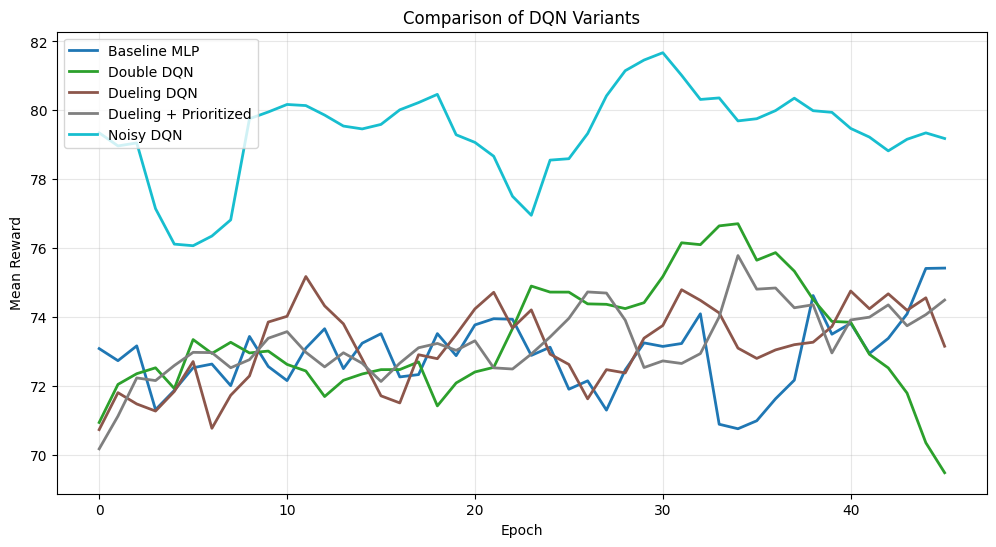

In [94]:
# ============================================================================
# 🧪 ЭКСПЕРИМЕНТ 1: Сравнение архитектур
# ============================================================================

# Конфигурации для сравнения
experiments_config = {
    "Baseline MLP": {
        "network_class": BaselineMLP,
        "use_double_dqn": False,
        "input_size": INPUT_NEURS_BY_MOB[0],
        "output_size": OUTPUT_NEURS_BY_MOB[0],
    },
    "Double DQN": {
        "network_class": BaselineMLP,
        "use_double_dqn": True,
        "input_size": INPUT_NEURS_BY_MOB[0],
        "output_size": OUTPUT_NEURS_BY_MOB[0],
    },
    "Dueling DQN": {
        "network_class": DuelingDQN,
        "use_double_dqn": True,
        "input_size": INPUT_NEURS_BY_MOB[0],
        "output_size": OUTPUT_NEURS_BY_MOB[0],
    },
    "Dueling + Prioritized": {
        "network_class": DuelingDQN,
        "use_double_dqn": True,
        "use_prioritized": True,
        "input_size": INPUT_NEURS_BY_MOB[0],
        "output_size": OUTPUT_NEURS_BY_MOB[0],
    },
    "Noisy DQN": {
        "network_class": NoisyDQN,
        "use_double_dqn": True,
        "input_size": INPUT_NEURS_BY_MOB[0],
        "output_size": OUTPUT_NEURS_BY_MOB[0],
    },
}

# Раскомментируй для запуска:
results = {}
for name, config in experiments_config.items():
    print(f"\n{'='*50}")
    print(f"🔬 Running: {name}")
    print('='*50)
    agent = DQNAgent(**config)
    rewards, losses = train_agent(agent, mob_id=0, n_epochs=50, games_per_epoch=20)
    results[name] = rewards
    agent.save(f"../saved_models/exp_{name.replace(' ', '_')}.pt")

compare_experiments(results)


In [ ]:
# ============================================================================
# 🧪 ЭКСПЕРИМЕНТ 2: Поиск гиперпараметров
# ============================================================================

hyperparams_grid = {
    "lr": [1e-5, 1e-4, 1e-3],
    "gamma": [0.9, 0.95, 0.99],
    "batch_size": [32, 64, 128],
    "target_update_freq": [50, 100, 200],
}

# Для полного grid search раскомментируй:
# from itertools import product
# 
# param_combinations = list(product(*hyperparams_grid.values()))
# param_names = list(hyperparams_grid.keys())
# 
# best_reward = float('-inf')
# best_params = None
# 
# for params in param_combinations:
#     config = dict(zip(param_names, params))
#     print(f"Testing: {config}")
#     agent = DQNAgent(network_class=DuelingDQN, **config)
#     rewards, _ = train_agent(agent, n_epochs=20, games_per_epoch=10, verbose=False)
#     mean_final = np.mean(rewards[-5:])
#     if mean_final > best_reward:
#         best_reward = mean_final
#         best_params = config
# 
# print(f"Best params: {best_params}, reward: {best_reward:.2f}")


In [ ]:
# ============================================================================
# 🧪 ЭКСПЕРИМЕНТ 3: Быстрый тест
# ============================================================================

# Быстрый тест одного агента - раскомментируй для запуска:
# agent = DQNAgent(
#     network_class=DuelingDQN,
#     lr=1e-4,
#     gamma=0.95,
#     use_double_dqn=True,
#     use_prioritized=True,
# )
# 
# rewards, losses = train_agent(
#     agent, 
#     mob_id=0,  # JawWorm
#     n_epochs=30,
#     games_per_epoch=30,
#     epsilon_start=0.3,
#     epsilon_decay=0.95,
# )
# 
# plot_training(rewards, losses, "Dueling Double DQN + PER")



🔬 Running: Noisy DQN (baseline)
🎯 Training against JawWorm
Epoch   0 | Reward:   54.11 | Loss: 4.0522 | ε: 0.297
Epoch   5 | Reward:   77.12 | Loss: 3.3831 | ε: 0.282
Epoch  10 | Reward:   80.08 | Loss: 2.9746 | ε: 0.269
Epoch  15 | Reward:   79.06 | Loss: 2.7547 | ε: 0.255
Epoch  20 | Reward:   78.84 | Loss: 2.5602 | ε: 0.243
Epoch  25 | Reward:   79.33 | Loss: 2.0887 | ε: 0.231
Epoch  30 | Reward:   68.36 | Loss: 2.6600 | ε: 0.220
Epoch  35 | Reward:   81.19 | Loss: 3.1862 | ε: 0.209
Epoch  40 | Reward:   77.17 | Loss: 2.2646 | ε: 0.199
Epoch  45 | Reward:   81.16 | Loss: 1.7380 | ε: 0.189

🔬 Running: Noisy + Dueling
🎯 Training against JawWorm
Epoch   0 | Reward:   31.54 | Loss: 3.9383 | ε: 0.297
Epoch   5 | Reward:   67.18 | Loss: 3.4398 | ε: 0.282
Epoch  10 | Reward:   75.65 | Loss: 3.3637 | ε: 0.269
Epoch  15 | Reward:   77.76 | Loss: 3.3481 | ε: 0.255
Epoch  20 | Reward:   73.66 | Loss: 3.4239 | ε: 0.243
Epoch  25 | Reward:   72.47 | Loss: 3.2396 | ε: 0.231
Epoch  30 | Reward:  

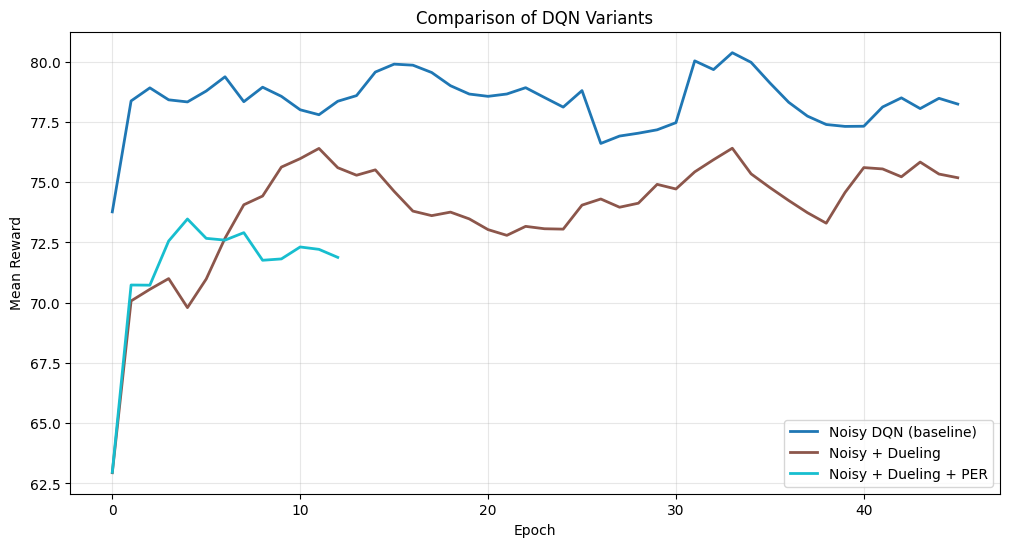

In [96]:
# ============================================================================
# 🧪 ЭКСПЕРИМЕНТ 4: Noisy DQN - углублённые эксперименты
# ============================================================================

# Noisy + Dueling (комбинация лучших)
class NoisyDuelingDQN(nn.Module):
    """Noisy Dueling DQN - комбинация двух лучших подходов"""
    def __init__(self, input_size, output_size, hidden=256):
        super().__init__()
        
        # Feature extractor (обычные слои)
        self.feature = nn.Sequential(
            nn.Linear(input_size, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU()
        )
        
        # Value stream с Noisy layers
        self.value_noisy1 = NoisyLinear(hidden, 128)
        self.value_noisy2 = NoisyLinear(128, 1)
        
        # Advantage stream с Noisy layers
        self.adv_noisy1 = NoisyLinear(hidden, 128)
        self.adv_noisy2 = NoisyLinear(128, output_size)
    
    def forward(self, x):
        features = self.feature(x)
        
        value = F.relu(self.value_noisy1(features))
        value = self.value_noisy2(value)
        
        advantage = F.relu(self.adv_noisy1(features))
        advantage = self.adv_noisy2(advantage)
        
        q_values = value + advantage - advantage.mean(dim=1, keepdim=True)
        return q_values
    
    def reset_noise(self):
        self.value_noisy1.reset_noise()
        self.value_noisy2.reset_noise()
        self.adv_noisy1.reset_noise()
        self.adv_noisy2.reset_noise()


# Эксперименты с Noisy вариантами
noisy_experiments = {
    "Noisy DQN (baseline)": {
        "network_class": NoisyDQN,
        "use_double_dqn": True,
        "input_size": INPUT_NEURS_BY_MOB[0],
        "output_size": OUTPUT_NEURS_BY_MOB[0],
    },
    "Noisy + Dueling": {
        "network_class": NoisyDuelingDQN,
        "use_double_dqn": True,
        "input_size": INPUT_NEURS_BY_MOB[0],
        "output_size": OUTPUT_NEURS_BY_MOB[0],
    },
    "Noisy + Dueling + PER": {
        "network_class": NoisyDuelingDQN,
        "use_double_dqn": True,
        "use_prioritized": True,
        "input_size": INPUT_NEURS_BY_MOB[0],
        "output_size": OUTPUT_NEURS_BY_MOB[0],
    },
}

# Раскомментируй для запуска:
noisy_results = {}
for name, config in noisy_experiments.items():
    print(f"\n{'='*50}")
    print(f"🔬 Running: {name}")
    print('='*50)
    agent = DQNAgent(**config, lr=1e-4, gamma=0.95)
    rewards, losses = train_agent(agent, mob_id=0, n_epochs=50, games_per_epoch=20)
    noisy_results[name] = rewards

compare_experiments(noisy_results)



🔬 Running: Noisy σ=0.3 (low)
🎯 Training against JawWorm
   Final reward: 73.19

🔬 Running: Noisy σ=0.5 (default)
🎯 Training against JawWorm
   Final reward: 79.54

🔬 Running: Noisy σ=0.7 (high)
🎯 Training against JawWorm
   Final reward: 73.14

🔬 Running: Noisy + lr=5e-4
🎯 Training against JawWorm
   Final reward: 79.74

🔬 Running: Noisy + lr=1e-3
🎯 Training against JawWorm
   Final reward: 80.00


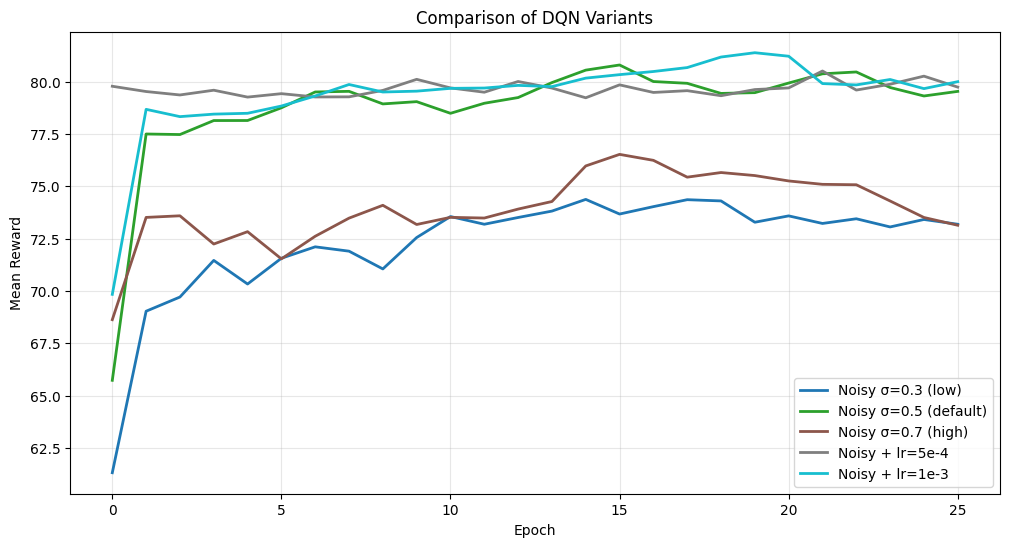

In [97]:
# ============================================================================
# 🧪 ЭКСПЕРИМЕНТ 5: Гиперпараметры для Noisy DQN
# ============================================================================

# Разные sigma для Noisy layers
class NoisyDQN_LowNoise(nn.Module):
    """Noisy DQN с меньшим шумом (sigma=0.3)"""
    def __init__(self, input_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 256)
        self.noisy1 = NoisyLinear(256, 128, sigma_init=0.3)
        self.noisy2 = NoisyLinear(128, output_size, sigma_init=0.3)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.noisy1(x))
        return self.noisy2(x)
    
    def reset_noise(self):
        self.noisy1.reset_noise()
        self.noisy2.reset_noise()


class NoisyDQN_HighNoise(nn.Module):
    """Noisy DQN с большим шумом (sigma=0.7)"""
    def __init__(self, input_size, output_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 128)
        self.fc2 = nn.Linear(128, 256)
        self.noisy1 = NoisyLinear(256, 128, sigma_init=0.7)
        self.noisy2 = NoisyLinear(128, output_size, sigma_init=0.7)
    
    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.noisy1(x))
        return self.noisy2(x)
    
    def reset_noise(self):
        self.noisy1.reset_noise()
        self.noisy2.reset_noise()


# Эксперименты с разными уровнями шума и lr
noise_hyperparams = {
    "Noisy σ=0.3 (low)": {"network_class": NoisyDQN_LowNoise, "lr": 1e-4},
    "Noisy σ=0.5 (default)": {"network_class": NoisyDQN, "lr": 1e-4},
    "Noisy σ=0.7 (high)": {"network_class": NoisyDQN_HighNoise, "lr": 1e-4},
    "Noisy + lr=5e-4": {"network_class": NoisyDQN, "lr": 5e-4},
    "Noisy + lr=1e-3": {"network_class": NoisyDQN, "lr": 1e-3},
}

# Раскомментируй для запуска:
hp_results = {}
for name, config in noise_hyperparams.items():
    print(f"\n🔬 Running: {name}")
    agent = DQNAgent(input_size=INPUT_NEURS_BY_MOB[0], output_size=OUTPUT_NEURS_BY_MOB[0], use_double_dqn=True, gamma=0.95, **config)
    rewards, _ = train_agent(agent, mob_id=0, n_epochs=30, games_per_epoch=20, verbose=False)
    hp_results[name] = rewards
    print(f"   Final reward: {np.mean(rewards[-5:]):.2f}")

compare_experiments(hp_results)


In [98]:
# ============================================================================
# 🏆 ФИНАЛЬНОЕ ОБУЧЕНИЕ: Noisy DQN на JawWorm и Cultist
# ============================================================================

def evaluate_model(model, mob_id, n_games=50):
    """Оценка модели без обучения"""
    emulator = STSEmulator()
    emulator.start()
    
    rewards = []
    wins = 0
    
    try:
        for _ in range(n_games):
            total_reward = 0
            
            reward, state, actions = emulator.reset()
            total_reward += reward
            
            reward, state, actions = emulator.send(mob_id)
            total_reward += reward
            l_state = state_to_tuple(state, INPUT_NEURS_BY_MOB[mob_id])
            
            done = False
            while not done:
                # Greedy action (no exploration)
                with torch.no_grad():
                    state_tensor = torch.FloatTensor(l_state).unsqueeze(0).to(device)
                    q_values = model(state_tensor)
                    action = q_values[0, :len(actions)].argmax().item()
                
                reward, next_state, next_actions = emulator.send(action)
                if reward is None:
                    break
                    
                total_reward += reward
                done = next_state["game_state"] in [1, 2]
                
                if done and next_state["game_state"] == 2:  # Win
                    wins += 1
                
                l_state = state_to_tuple(next_state, INPUT_NEURS_BY_MOB[mob_id])
                actions = next_actions
            
            rewards.append(total_reward)
    finally:
        emulator.close()
    
    return np.mean(rewards), np.std(rewards), wins / n_games * 100


🚀 Training Noisy DQN on JawWorm (100 epochs)...
🎯 Training against JawWorm
Epoch   0 | Reward:   16.69 | Loss: 2.8410 | ε: 0.297
Epoch   5 | Reward:   44.93 | Loss: 4.1797 | ε: 0.282
Epoch  10 | Reward:   44.47 | Loss: 4.9261 | ε: 0.269
Epoch  15 | Reward:   44.55 | Loss: 5.9211 | ε: 0.255
Epoch  20 | Reward:   44.15 | Loss: 5.8906 | ε: 0.243
Epoch  25 | Reward:   43.64 | Loss: 5.5111 | ε: 0.231
Epoch  30 | Reward:   44.03 | Loss: 5.1708 | ε: 0.220
Epoch  35 | Reward:   41.12 | Loss: 3.8787 | ε: 0.209
Epoch  40 | Reward:   41.62 | Loss: 2.4618 | ε: 0.199
⚠️ HIGH LOSS: 541.89
   current_q: [-34543.91, 64.55]
   target_q: [-15.00, 68.35]
⚠️ HIGH LOSS: 386.27
   current_q: [-18840.73, 5831.03]
   target_q: [-15.00, 95.00]
⚠️ HIGH LOSS: 478.95
   current_q: [8.05, 30614.53]
   target_q: [13.66, 100.00]
⚠️ HIGH LOSS: 130.71
   current_q: [10.73, 8296.78]
   target_q: [7.30, 100.00]
Epoch  45 | Reward:   43.20 | Loss: 2.5521 | ε: 0.189
⚠️ HIGH LOSS: 137.36
   current_q: [-8669.66, 64.09]
   

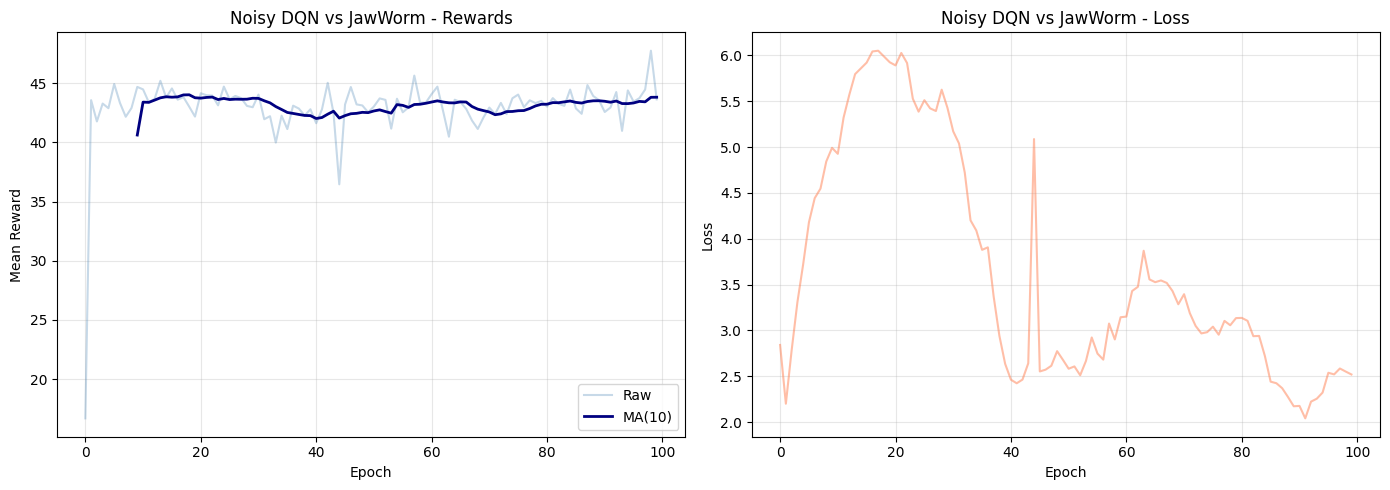

In [147]:
# Обучение на JawWorm
print("🚀 Training Noisy DQN on JawWorm (100 epochs)...")
agent_jw = DQNAgent(
    network_class=NoisyDQN,
    lr=1e-3,
    gamma=0.95,
    use_double_dqn=True,
    buffer_size=20000,
    batch_size=64,
    input_size=INPUT_NEURS_BY_MOB[0],
    output_size=OUTPUT_NEURS_BY_MOB[0],
)

rewards_jw, losses_jw = train_agent(
    agent_jw, 
    mob_id=0,  # JawWorm
    n_epochs=100,
    games_per_epoch=30,
)

plot_training(rewards_jw, losses_jw, "Noisy DQN vs JawWorm")
agent_jw.save("../saved_models/NoisyDQN_JawWorm_v2.pt")


🚀 Training Noisy DQN on Cultist (100 epochs)...
🎯 Training against Cultist
Epoch   0 | Reward:    1.75 | Loss: 5.2370 | ε: 0.297
Epoch   5 | Reward:   48.41 | Loss: 2.4317 | ε: 0.282
Epoch  10 | Reward:   48.83 | Loss: 2.6621 | ε: 0.269
Epoch  15 | Reward:   47.15 | Loss: 2.6114 | ε: 0.255
Epoch  20 | Reward:   49.92 | Loss: 2.5916 | ε: 0.243
Epoch  25 | Reward:   46.27 | Loss: 2.7556 | ε: 0.231
Epoch  30 | Reward:   46.90 | Loss: 2.8390 | ε: 0.220
Epoch  35 | Reward:   50.31 | Loss: 2.6433 | ε: 0.209
Epoch  40 | Reward:   49.02 | Loss: 2.9319 | ε: 0.199
Epoch  45 | Reward:   49.16 | Loss: 2.9487 | ε: 0.189
Epoch  50 | Reward:   48.73 | Loss: 2.7797 | ε: 0.180
Epoch  55 | Reward:   47.85 | Loss: 2.8617 | ε: 0.171
Epoch  60 | Reward:   45.73 | Loss: 2.7256 | ε: 0.163
Epoch  65 | Reward:   47.56 | Loss: 2.5379 | ε: 0.155
Epoch  70 | Reward:   51.13 | Loss: 2.5192 | ε: 0.147
Epoch  75 | Reward:   44.48 | Loss: 2.4736 | ε: 0.140
Epoch  80 | Reward:   48.32 | Loss: 2.2714 | ε: 0.133
Epoch 

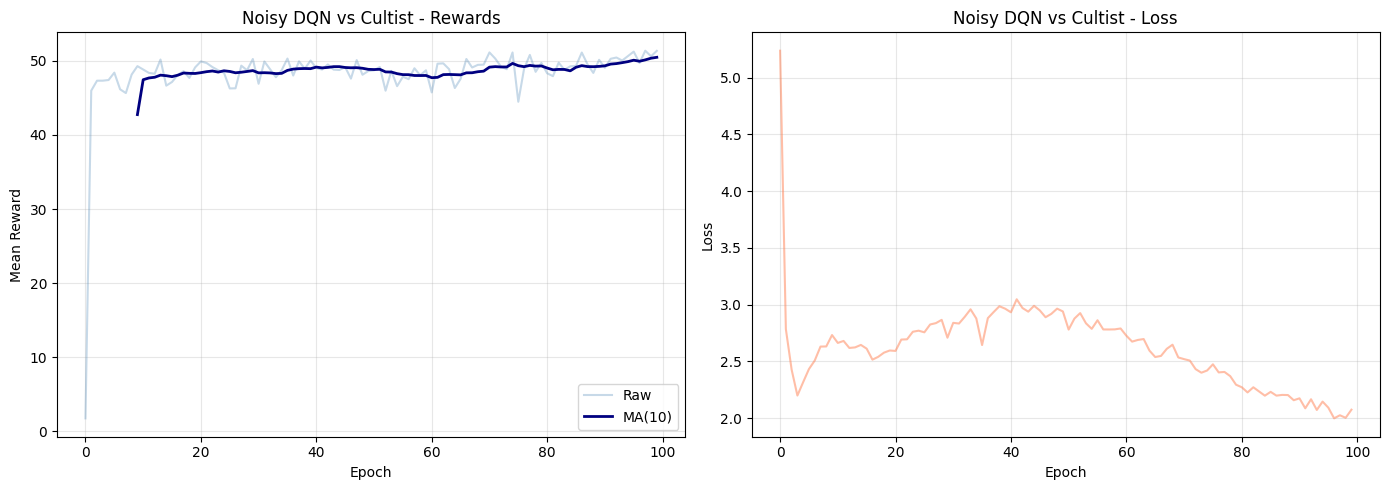

In [148]:
# Обучение на Cultist
print("\n🚀 Training Noisy DQN on Cultist (100 epochs)...")
agent_cult = DQNAgent(
    network_class=NoisyDQN,
    lr=1e-4,
    gamma=0.95,
    use_double_dqn=True,
    buffer_size=20000,
    batch_size=64,
    input_size=INPUT_NEURS_BY_MOB[1],
    output_size=OUTPUT_NEURS_BY_MOB[1],
)

rewards_cult, losses_cult = train_agent(
    agent_cult, 
    mob_id=1,  # Cultist
    n_epochs=100,
    games_per_epoch=30,
)

plot_training(rewards_cult, losses_cult, "Noisy DQN vs Cultist")
agent_cult.save("../saved_models/NoisyDQN_Cultist_v2.pt")


🚀 Training Noisy DQN on Louses...
🎯 Training against Louses
Epoch   0 | Reward:   26.44 | Loss: 3.4347 | ε: 0.297
Epoch   5 | Reward:   30.05 | Loss: 2.8776 | ε: 0.282
Epoch  10 | Reward:   30.75 | Loss: 2.0109 | ε: 0.269
Epoch  15 | Reward:   29.61 | Loss: 2.6290 | ε: 0.255
Epoch  20 | Reward:   31.49 | Loss: 15.2210 | ε: 0.243
Epoch  25 | Reward:   31.10 | Loss: 8.1866 | ε: 0.231
Epoch  30 | Reward:   28.48 | Loss: 7.9673 | ε: 0.220
Epoch  35 | Reward:   32.30 | Loss: 7.4736 | ε: 0.209
Epoch  40 | Reward:   31.66 | Loss: 7.7722 | ε: 0.199
Epoch  45 | Reward:   30.07 | Loss: 7.6287 | ε: 0.189
Epoch  50 | Reward:   28.58 | Loss: 7.4306 | ε: 0.180
Epoch  55 | Reward:   33.65 | Loss: 7.3734 | ε: 0.171
Epoch  60 | Reward:   25.75 | Loss: 7.4287 | ε: 0.163
Epoch  65 | Reward:   32.47 | Loss: 7.2980 | ε: 0.155
Epoch  70 | Reward:   31.53 | Loss: 7.5993 | ε: 0.147
Epoch  75 | Reward:   31.80 | Loss: 7.2390 | ε: 0.140
Epoch  80 | Reward:   32.53 | Loss: 6.9443 | ε: 0.133
Epoch  85 | Reward:  

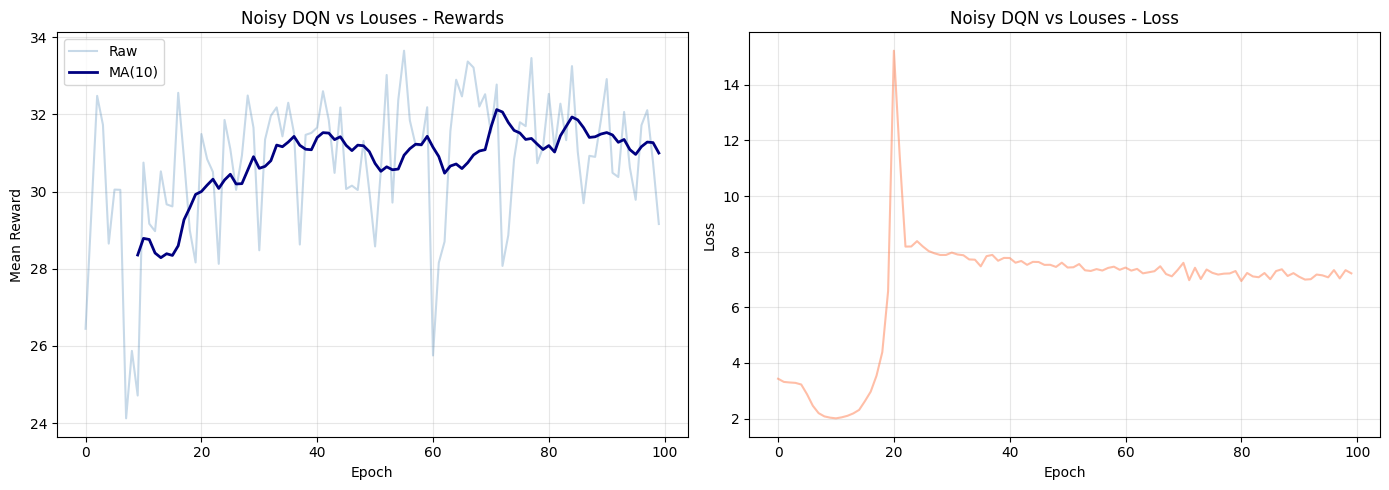

In [151]:
# ============================================================================
# 🧪 Louses с улучшенными гиперпараметрами
# ============================================================================

print("🚀 Training Noisy DQN on Louses...")

agent_louses_v3 = DQNAgent(
    network_class=NoisyDQN,
    lr=1e-5,
    gamma=0.95,
    use_double_dqn=True,
    buffer_size=20000,
    batch_size=64,
    input_size=INPUT_NEURS_BY_MOB[2],
    output_size=OUTPUT_NEURS_BY_MOB[2],
    weight_decay=1e-5,
    use_soft_clipping=True,
)

rewards_louses, losses_louses = train_agent(
    agent_louses_v3, 
    mob_id=2,  # Louses
    n_epochs=100,
    games_per_epoch=50,
)

plot_training(rewards_louses, losses_louses, "Noisy DQN vs Louses")
agent_louses_v3.save("../saved_models/NoisyDQN_Louses_v2.pt")


In [139]:
# ============================================================================
# 📊 Сравнение: обученный агент vs случайный
# ============================================================================

def evaluate_agent(agent, mob_id, n_games=50, random_policy=False):
    """Оценка агента на n_games играх"""
    emulator = STSEmulator()
    emulator.start()
    
    total_rewards = []
    wins = 0
    
    for _ in range(n_games):
        game_reward = 0
        
        # Reset и выбор моба
        reward, state, actions = emulator.reset()
        game_reward += reward
        
        reward, state, actions = emulator.send(mob_id)
        game_reward += reward
        l_state = state_to_tuple(state, INPUT_NEURS_BY_MOB[mob_id])
        
        done = False
        while not done:
            if random_policy:
                action = random.randrange(len(actions))
            else:
                action = agent.get_action(l_state, len(actions), epsilon=0)
            
            reward, next_state, next_actions = emulator.send(action)
            if reward is None:
                break
            
            game_reward += reward
            done = next_state["game_state"] in [1, 2]
            
            if next_state["game_state"] == 2:  # Win
                wins += 1
            
            l_state = state_to_tuple(next_state, INPUT_NEURS_BY_MOB[mob_id])
            actions = next_actions
        
        total_rewards.append(game_reward)
    
    emulator.close()
    
    return {
        "mean_reward": np.mean(total_rewards),
        "std_reward": np.std(total_rewards),
        "win_rate": wins / n_games * 100,
        "min_reward": np.min(total_rewards),
        "max_reward": np.max(total_rewards),
    }

# Оценка случайного агента на Louses
print("📊 Evaluating RANDOM agent on Louses...")
random_stats = evaluate_agent(None, mob_id=2, n_games=100, random_policy=True)
print(f"Random Agent: reward={random_stats['mean_reward']:.1f}±{random_stats['std_reward']:.1f}, win_rate={random_stats['win_rate']:.1f}%")

# Оценка обученного агента
print("\n📊 Evaluating TRAINED agent on Louses...")
trained_stats = evaluate_agent(agent_louses_v3, mob_id=2, n_games=100, random_policy=False)
print(f"Trained Agent: reward={trained_stats['mean_reward']:.1f}±{trained_stats['std_reward']:.1f}, win_rate={trained_stats['win_rate']:.1f}%")

print(f"\n🎯 Improvement: {trained_stats['mean_reward'] - random_stats['mean_reward']:.1f} reward, "
      f"{trained_stats['win_rate'] - random_stats['win_rate']:.1f}% win rate")


📊 Evaluating RANDOM agent on Louses...
Random Agent: reward=19.3±14.7, win_rate=99.0%

📊 Evaluating TRAINED agent on Louses...
Trained Agent: reward=31.7±5.5, win_rate=100.0%

🎯 Improvement: 12.4 reward, 1.0% win rate


# 📝 TODO / Идеи для экспериментов

## Улучшения DQN
- **Rainbow DQN** - объединить все улучшения: Double, Dueling, PER, Noisy, N-step, Distributional
- **N-step returns** - использовать n-шаговые награды вместо одношаговых
- **Categorical DQN (C51)** - предсказывать распределение Q-values

## Альтернативные алгоритмы
- **A2C/A3C** - Advantage Actor-Critic
- **PPO** - Proximal Policy Optimization (более стабильный policy gradient)
- **SAC** - Soft Actor-Critic (с entropy regularization)

## Архитектурные улучшения
- **Attention** - добавить attention механизм для карт в руке
- **LSTM/GRU** - учитывать историю ходов
- **Transformer** - self-attention для всего состояния

## Обучение
- **Curriculum Learning** - начать с простых мобов, постепенно усложнять
- **Multi-task** - одна сеть для всех мобов
- **Reward shaping** - более информативные награды (например, бонус за убийство моба)
- **Self-play** - если добавить PvP режим

## Инфраструктура
- **Tensorboard** - логирование метрик
- **Weights & Biases** - эксперименты tracking
- **Optuna** - автоматический hyperparameter search
